# Example for photon dose calculation using pencilbeam engine.

C:\NiklasLocal\python\pyRadPlan\.venv313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Beam:   0%|          | 0/1 [00:00<?, ?b/s]

Beam:   0%|          | 0/1 [00:00<?, ?b/s]

C:\NiklasLocal\python\pyRadPlan\pyRadPlan\raytracer\_siddon.py:359: RuntimeWarning: divide by zero encountered in divide
  (p_min - self._source_points) / self._ray_vec,  # alpha to "near" plane
C:\NiklasLocal\python\pyRadPlan\pyRadPlan\raytracer\_siddon.py:360: RuntimeWarning: divide by zero encountered in divide
  (p_max - self._source_points) / self._ray_vec,
C:\NiklasLocal\python\pyRadPlan\.venv313\Lib\site-packages\numpy\lib\_function_base_impl.py:1518: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
C:\NiklasLocal\python\pyRadPlan\pyRadPlan\raytracer\_siddon.py:429: RuntimeWarning: invalid value encountered in multiply
  ijk = sp_scaled[:, :, None] + rv_scaled[:, :, None] * alphas_mid[:, None, :]


Ray:   0%|          | 0/340 [00:00<?, ?r/s]

...

Ray:  68%|██████▊   | 232/340 [00:00<00:00, 459.52r/s]

Ray:  82%|████████▏ | 280/340 [00:00<00:00, 464.90r/s]

Ray:  96%|█████████▌| 327/340 [00:00<00:00, 456.83r/s]

Beam: 100%|██████████| 1/1 [00:01<00:00,  1.13s/b]

C:\NiklasLocal\python\pyRadPlan\pyRadPlan\optimization\problems\_optiprob.py:110: UserWarning: Solver ipopt not available. Choose from ['scipy'], and we will choose the first available one for you!
  warnings.warn(


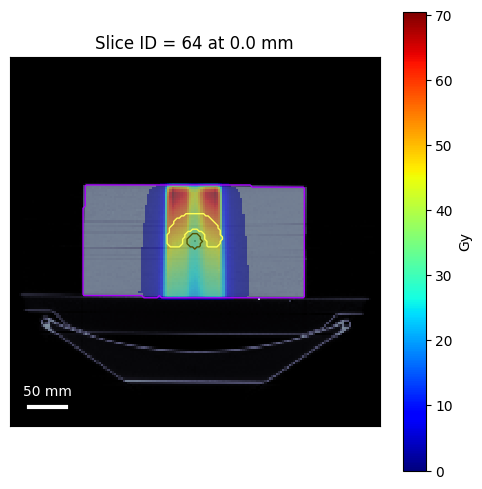

In [1]:
# Necessary imports
from pyRadPlan import (
    load_tg119,
    PhotonPlan,
    generate_stf,
    calc_dose_influence,
    fluence_optimization,
    plot_slice,
)

#  Read patient from provided TG119.mat file and validate data
ct, cst = load_tg119()

# Create a plan object
pln = PhotonPlan()

# Generate Steering Geometry ("stf")
stf = generate_stf(ct, cst, pln)

# Calculate Dose Influence Matrix ("dij")
dij = calc_dose_influence(ct, cst, stf, pln)

# Fluence Optimization (objectives loaded from "cst")
fluence = fluence_optimization(ct, cst, stf, dij, pln)

# Result
result = dij.compute_result_ct_grid(fluence)

# Plot
plot_slice(
    image_volume=ct,
    cst=cst,
    overlay=result["physical_dose"],
    overlay_unit="Gy",
)